In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# The hydrophobic effect, from six solubilities (Illustration 11.4-4)

This notebook works **Illustration 11.4-4** -- the Gibbs energy of transfer of
L-asparagine from water to ethanol, from nothing but two saturation solubilities -- and
then runs the same calculation on the six amino acids of **Problems 11.4-6 and 11.4-7**.

**Why two solubilities are enough.** When the same solid sits in equilibrium with two
saturated solutions, its fugacity is the same in both. So $x^W\gamma^W = x^E\gamma^E$,
and the activity coefficient ratio is the inverse solubility ratio. Everything about the
solid -- its fugacity, melting point, enthalpy of fusion -- cancels and never has to be
known. Equation 11.4-17 then turns that ratio into a Gibbs energy:

$$\Delta_{\rm tfr}G = RT\ln\frac{(\gamma_S^\infty)_{\rm solvent\ 2}}
                                {(\gamma_S^\infty)_{\rm solvent\ 1}}$$

**What the four amino acids of Problem 11.4-7 add.** They are a homologous series --
glycine, then the same molecule with a methyl, an ethyl, and an *n*-butyl side chain --
so the difference between consecutive members is one CH$_2$ group and nothing else. The
Gibbs energy of transfer therefore comes out as a group contribution, which is the
quantitative form of the hydrophobic effect. Neither problem asks for that; it falls out
when the six are put on one plot.

**And one pair the problems do not connect.** Problem 11.4-6's L-leucine and
Problem 11.4-7's $\alpha$-amino-*n*-caproic acid are structural isomers -- both have a
C$_4$H$_9$ side chain, branched in one and straight in the other. Their transfer energies
differ, which is a shape effect at fixed composition.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo.partition import (x_from_molarity, gamma_ratio_from_solubility,
                              gibbs_energy_of_transfer)

use_book_style()

T = 298.15
MOLES_WATER_PER_KG = 55.51        # SIS's value
MOLES_ETHANOL_PER_KG = 21.707     # SIS's value

# --- Illustration 11.4-4: L-asparagine --------------------------------------
S_W, S_E = 0.186, 2.3e-5          # saturation molarity in water and in ethanol

x_W = x_from_molarity(S_W, MOLES_WATER_PER_KG)
x_E = x_from_molarity(S_E, MOLES_ETHANOL_PER_KG)
ratio = gamma_ratio_from_solubility(x_W, x_E)
dG = gibbs_energy_of_transfer(ratio, T)

print("  Illustration 11.4-4, L-asparagine from water to ethanol")
print(f"    x_A in water   = {x_W:.4e}      SIS 3.34e-3")
print(f"    x_A in ethanol = {x_E:.4e}      SIS 1.06e-6")
print(f"    gamma^E/gamma^W = {ratio:.4g}         SIS 3.15e3")
print(f"    Delta_tfr G = RT ln(ratio) = {dG:,.0f} J/mol    SIS 19 970")
print(f"    (from SIS's own rounded 3150: {gibbs_energy_of_transfer(3150, T):,.0f} J/mol)")
print(f"\n    positive, so the transfer is unfavorable: work must be supplied to move")
print(f"    L-asparagine from water into ethanol.")

  Illustration 11.4-4, L-asparagine from water to ethanol
    x_A in water   = 3.3396e-03      SIS 3.34e-3
    x_A in ethanol = 1.0596e-06      SIS 1.06e-6
    gamma^E/gamma^W = 3152         SIS 3.15e3
    Delta_tfr G = RT ln(ratio) = 19,970 J/mol    SIS 19 970
    (from SIS's own rounded 3150: 19,968 J/mol)

    positive, so the transfer is unfavorable: work must be supplied to move
    L-asparagine from water into ethanol.



## The same calculation, six times

Problem 11.4-6 gives L-leucine and Problem 11.4-7 gives four more amino acids as a table
of solubilities in water and in ethanol, in mol/dm³. Every one is the identical
three-line reduction, so it is written once and run over the table.

The side chain R is what distinguishes them, in the amino acid
$^+{\rm H_3NCHRCOO^-}$: R = H is glycine, CH$_3$ is $\alpha$-alanine, C$_2$H$_5$ is
$\alpha$-amino-*n*-butyric acid, and C$_4$H$_9$ is $\alpha$-amino-*n*-caproic acid.

In [3]:

# name, side chain R, carbons in R, S_W (mol/dm^3), S_E (mol/dm^3), source
AMINO_ACIDS = [
    ("Glycine",                     "H",       0, 2.89,   3.9e-4,  "Prob. 11.4-7"),
    ("alpha-Alanine",               "CH3",     1, 1.66,   7.6e-4,  "Prob. 11.4-7"),
    ("alpha-Amino-n-butyric acid",  "C2H5",    2, 1.80,   2.6e-3,  "Prob. 11.4-7"),
    ("alpha-Amino-n-caproic acid",  "C4H9",    4, 0.0866, 1.04e-3, "Prob. 11.4-7"),
    ("L-Leucine",                   "C4H9*",   4, 0.171,  1.28e-3, "Prob. 11.4-6"),
    ("L-Asparagine",                "CH2CONH2", 2, S_W,   S_E,     "Ill. 11.4-4"),
]

print(f"  {'amino acid':28s} {'R':9s} {'x_W':>10s} {'x_E':>10s} {'gamma ratio':>12s}"
      f" {'dG (kJ/mol)':>12s}")
results = {}
for nm, R, nC, sw, se, src in AMINO_ACIDS:
    xw = x_from_molarity(sw, MOLES_WATER_PER_KG)
    xe = x_from_molarity(se, MOLES_ETHANOL_PER_KG)
    r = gamma_ratio_from_solubility(xw, xe)
    g = gibbs_energy_of_transfer(r, T)
    results[nm] = (nC, g, R)
    print(f"  {nm:28s} {R:9s} {xw:10.3e} {xe:10.3e} {r:12.1f} {g/1000:12.2f}")

print("\n  Every one is positive: ethanol is the worse solvent for all six, which is")
print("  what one expects of a zwitterion. What varies is by how much.")

  amino acid                   R                x_W        x_E  gamma ratio  dG (kJ/mol)
  Glycine                      H          4.949e-02  1.797e-05       2754.4        19.64
  alpha-Alanine                CH3        2.904e-02  3.501e-05        829.4        16.66
  alpha-Amino-n-butyric acid   C2H5       3.141e-02  1.198e-04        262.3        13.81
  alpha-Amino-n-caproic acid   C4H9       1.558e-03  4.791e-05         32.5         8.63
  L-Leucine                    C4H9*      3.071e-03  5.896e-05         52.1         9.80
  L-Asparagine                 CH2CONH2   3.340e-03  1.060e-06       3151.8        19.97

  Every one is positive: ethanol is the worse solvent for all six, which is
  what one expects of a zwitterion. What varies is by how much.



## One CH$_2$ group at a time

Take the four members of the homologous series in order of side-chain carbons. The
difference between consecutive members is the transfer energy of the group that was
added, and nothing else -- the charged head group, the temperature, and both solvents are
identical down the series.

In [4]:

series = [(results[n][0], results[n][1], n) for n in
          ("Glycine", "alpha-Alanine", "alpha-Amino-n-butyric acid",
           "alpha-Amino-n-caproic acid")]
nC = np.array([s[0] for s in series], dtype=float)
dGs = np.array([s[1] for s in series])

print("  Increment per CH2 added")
for (n1, g1, a), (n2, g2, b) in zip(series[:-1], series[1:]):
    print(f"    {a:28s} -> {b:28s} {(g2-g1)/1000/(n2-n1):+6.2f} kJ/mol per CH2")

slope, intercept = np.polyfit(nC, dGs, 1)
resid = dGs - (slope * nC + intercept)
print(f"\n  Least squares over the four: {slope/1000:+.2f} kJ/mol per CH2,")
print(f"  intercept {intercept/1000:.2f} kJ/mol at R = H")
print(f"  rms residual {np.sqrt((resid**2).mean())/1000:.2f} kJ/mol")

print(f"\n  And the two isomers, both with a C4H9 side chain:")
for n in ("alpha-Amino-n-caproic acid", "L-Leucine"):
    print(f"    {n:28s} {results[n][1]/1000:6.2f} kJ/mol")
d = results["L-Leucine"][1] - results["alpha-Amino-n-caproic acid"][1]
print(f"    branched minus straight: {d/1000:+.2f} kJ/mol -- a shape effect at fixed")
print(f"    molecular formula, and not quite half a CH2 group's worth.")

  Increment per CH2 added
    Glycine                      -> alpha-Alanine                 -2.98 kJ/mol per CH2
    alpha-Alanine                -> alpha-Amino-n-butyric acid    -2.85 kJ/mol per CH2
    alpha-Amino-n-butyric acid   -> alpha-Amino-n-caproic acid    -2.59 kJ/mol per CH2

  Least squares over the four: -2.74 kJ/mol per CH2,
  intercept 19.48 kJ/mol at R = H
  rms residual 0.14 kJ/mol

  And the two isomers, both with a C4H9 side chain:
    alpha-Amino-n-caproic acid     8.63 kJ/mol
    L-Leucine                      9.80 kJ/mol
    branched minus straight: +1.17 kJ/mol -- a shape effect at fixed
    molecular formula, and not quite half a CH2 group's worth.


**Each CH$_2$ group is worth about $-2.7$ kJ/mol of transfer energy** -- the three
consecutive increments are $-2.98$, $-2.85$ and $-2.59$, and a line through all four
members gives $-2.74$ with an rms residual of 0.14 kJ/mol. The sign is what the hydrophobic effect amounts
to: adding carbon to the side chain makes water the *worse*
solvent, so moving the molecule into ethanol becomes progressively less unfavorable. Four
printed solubilities give the group contribution, and the residual says how firmly.

Two things the plot below makes visible that the numbers alone do not.

**L-asparagine breaks the trend, and it is supposed to.** Its side chain has two carbons
like $\alpha$-amino-*n*-butyric acid, but they carry an amide group -- so it is polar
rather than hydrophobic, and it sits well above the line, at the transfer energy of
glycine. A group contribution counts groups, not carbon atoms.

**The two C$_4$H$_9$ isomers do not coincide.** Branching the side chain, from
*n*-butyl to isobutyl, costs 1.2 kJ/mol -- not quite half a CH$_2$ group. That is a real
effect, and it is the reason group-contribution methods like UNIFAC distinguish a CH$_3$
from a CH and count them separately (Sec. 9.6).

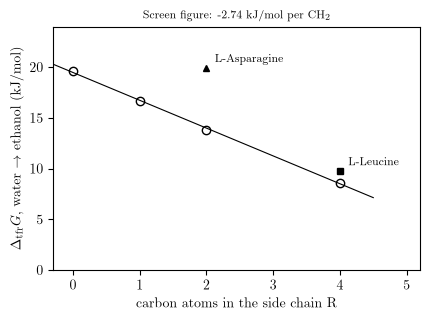

In [5]:

fig, ax = plt.subplots(figsize=(4.4, 3.3))

grid = np.linspace(-0.3, 4.5, 50)
ax.plot(grid, (slope * grid + intercept) / 1000, "-", color="k", lw=0.8)
ax.plot(nC, dGs / 1000, "o", mfc="none", mec="k", ms=6)
for n, marker, dy in (("L-Leucine", "s", 0.5), ("L-Asparagine", "^", 0.5)):
    c, g, R = results[n]
    ax.plot([c], [g / 1000], marker, mfc="k", mec="k", ms=5)
    ax.annotate(n, (c, g / 1000), textcoords="offset points", xytext=(6, 4),
                fontsize=8)

ax.set_xlabel("carbon atoms in the side chain R")
ax.set_ylabel(r"$\Delta_{\rm tfr}G$, water $\rightarrow$ ethanol (kJ/mol)")
ax.set_xlim(-0.3, 5.2); ax.set_ylim(0, 24)
ax.set_title(f"Screen figure: {slope/1000:+.2f} kJ/mol per CH$_2$", fontsize=8)
fig.tight_layout()
plt.show()


## What the calculation assumes, and where it would fail

Three assumptions, all of them stated in the illustration and each of them checkable.

**The saturated solutions stand in for infinitely dilute ones.** L-asparagine's mole
fractions are $3.3\times10^{-3}$ and $1.1\times10^{-6}$, so this is safe there. Glycine
is a different matter: its aqueous mole fraction at saturation is 0.049, five percent of
the solution, and calling $\gamma$ at that concentration an infinite-dilution value is a
stretch. The series' least-squares line is what absorbs the error, which is one reason to
fit four points rather than difference two.

**A molarity is treated as a molality.** The conversion uses 55.51 mol of water and
21.707 mol of ethanol per kilogram of *solvent*, while the solubilities are per cubic
decimeter of *solution*. For a 0.186 M solution the two differ by well under a percent;
for glycine at 2.89 M they do not.

**The solid is the same solid in both solvents.** If an amino acid crystallized as a
different polymorph or as a solvate from ethanol, its fugacity would not cancel and the
whole shortcut would collapse. Nothing in the data would reveal it, so a single
pair of solubilities carries an assumption that only a diffraction pattern can test.

## Your turn

1. Redo the glycine calculation treating the 2.89 M solubility properly as a molarity:
   convert with the density of a saturated aqueous glycine solution (about 1.09 g/cm³)
   and see how far $\Delta_{\rm tfr}G$ moves. Does the CH$_2$ increment survive?
2. The transfer energies here are water to ethanol. Predict the water-to-octanol values
   from them by assuming that ethanol and octanol differ only in how much CH$_2$ each
   contributes, and compare your prediction against the $K_{\rm OW}$ of glycine you can
   look up.
3. Add temperature. Section 11.4 gives $\Delta_{\rm tfr}G$ at 25 °C only. What
   measurement would give $\Delta_{\rm tfr}H$, and why is that the quantity that says
   whether the hydrophobic effect is entropic?
4. Use the CH$_2$ increment to predict the water-ethanol transfer energy of
   $\alpha$-amino-*n*-valeric acid (R = C$_3$H$_7$), then find a solubility measurement
   and check it.
5. UNIFAC (Sec. 9.6) has group parameters for CH$_2$, COOH and NH$_2$. Predict
   $\gamma^{W,\infty}$ for glycine and $\alpha$-alanine with it and compare with the
   ratio measured here. Where does a group-contribution method get into trouble with a
   zwitterion?